In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

In [3]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict
data = []
labels = []
for i in range(1, 6):
    batch = unpickle(f"data/cifar-10-batches-py/data_batch_{i}")
    data.append(batch[b'data'])
    labels.extend(batch[b'labels'])
X_train = np.vstack(data).reshape(-1, 3, 32, 32)  # shape: (50000, 3, 32, 32)
y_train = np.array(labels)
test_batch = unpickle("data/cifar-10-batches-py/test_batch")
X_test = test_batch[b'data'].reshape(-1, 3, 32, 32)
y_test = np.array(test_batch[b'labels'])
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

df_labels = pd.DataFrame(y_train, columns=["label"])
print(df_labels.head())

Train: (50000, 3, 32, 32) (50000,)
Test : (10000, 3, 32, 32) (10000,)
   label
0      6
1      9
2      9
3      4
4      1


In [4]:
X_train[0]

array([[[ 59,  43,  50, ..., 158, 152, 148],
        [ 16,   0,  18, ..., 123, 119, 122],
        [ 25,  16,  49, ..., 118, 120, 109],
        ...,
        [208, 201, 198, ..., 160,  56,  53],
        [180, 173, 186, ..., 184,  97,  83],
        [177, 168, 179, ..., 216, 151, 123]],

       [[ 62,  46,  48, ..., 132, 125, 124],
        [ 20,   0,   8, ...,  88,  83,  87],
        [ 24,   7,  27, ...,  84,  84,  73],
        ...,
        [170, 153, 161, ..., 133,  31,  34],
        [139, 123, 144, ..., 148,  62,  53],
        [144, 129, 142, ..., 184, 118,  92]],

       [[ 63,  45,  43, ..., 108, 102, 103],
        [ 20,   0,   0, ...,  55,  50,  57],
        [ 21,   0,   8, ...,  50,  50,  42],
        ...,
        [ 96,  34,  26, ...,  70,   7,  20],
        [ 96,  42,  30, ...,  94,  34,  34],
        [116,  94,  87, ..., 140,  84,  72]]],
      shape=(3, 32, 32), dtype=uint8)

In [5]:
# CIFAR-10 class names
class_names = [
    'airplane', 
    'automobile', 
    'bird', 
    'cat', 
    'deer',
    'dog', 
    'frog', 
    'horse', 
    'ship', 
    'truck']

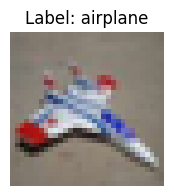

In [6]:
plt.figure(figsize=(2,2))
n = 30
plt.imshow(np.transpose(X_train[n], (1, 2, 0)))
y_label = y_train[n]
plt.title(f"Label: {class_names[y_label]}")
plt.axis('off')
plt.show()

In [7]:
X_train = np.transpose(X_train, (0,2,3,1))
X_test = np.transpose(X_test, (0,2,3,1))
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [14]:
n_samples = X_train.shape[0]
n_samples_test = X_test.shape[0]

In [12]:
X_train.reshape(n_samples, -1)

array([[ 59,  62,  63, ..., 123,  92,  72],
       [154, 177, 187, ..., 143, 133, 144],
       [255, 255, 255, ...,  80,  86,  84],
       ...,
       [ 35, 178, 235, ...,  12,  31,  50],
       [189, 211, 240, ..., 195, 190, 171],
       [229, 229, 239, ..., 163, 163, 161]],
      shape=(50000, 3072), dtype=uint8)

In [17]:
from sklearn.preprocessing import StandardScaler

std_scl = StandardScaler()
X_train = std_scl.fit_transform(X_train.reshape(n_samples, -1))
X_test = std_scl.transform(X_test.reshape(n_samples_test, -1))

In [19]:
from sklearn.decomposition import PCA

tsne = PCA(n_components=1000, random_state=42)
X_train_reduced = tsne.fit_transform(X_train)
X_test_reduced = tsne.fit_transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score


models = [("lr", LogisticRegression(max_iter=1000, n_jobs=-1)),
          ("rf_clf", GridSearchCV(estimator=RandomForestClassifier(), 
                                  param_grid={"n_estimators": [100], "max_depth": [8, 10, 15, 20], "n_jobs": [-1]})
          ),
          ("svc", SVC()),
          ("knn_clf", KNeighborsClassifier(n_jobs=-1)),
          ("bnb_clf", BernoulliNB())
         ]

for name, model in models:
    model.fit(X_train_reduced, y_train)
    y_pred = model.predict(X_train_reduced)
    y_test_pred = model.predict(X_test_reduced)
    print(f"{name} accuracy score on train dataset:", accuracy_score(y_train, y_pred))
    print(f"{name} accuracy score on test dataset:", accuracy_score(y_test, y_test_pred))

lr accuracy score on train dataset: 0.4635
lr accuracy score on test dataset: 0.1613
rf_clf accuracy score on train dataset: 0.68752
rf_clf accuracy score on test dataset: 0.1046
svc accuracy score on train dataset: 0.71216
svc accuracy score on test dataset: 0.1
knn_clf accuracy score on train dataset: 0.5084
knn_clf accuracy score on test dataset: 0.1571
bnb_clf accuracy score on train dataset: 0.37598
bnb_clf accuracy score on test dataset: 0.1436
